<a href="https://colab.research.google.com/github/Faiva-404/PemMes-Ganjil-2026/blob/main/Kuis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


```
Faiva Puspa Sahara_06_TI3A
```

> **Load Data and Inspect Metadata**

In [2]:
!pip install -q ucimlrepo

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [43]:
adult_income = fetch_ucirepo(id=2)

In [44]:
#Data
X = adult_income.data.features
y = adult_income.data.targets

#Concate Features and Target
df = pd.concat([X, y], axis=1)

#Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [45]:
df.shape

(48842, 15)

In [46]:
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex


> **Bagian 1 - Data Loading dan Data Imputation**

Soal 1
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?

In [47]:
#Jawab 1.1.1 - Inspeksi profile data
df.info()

#ukuran dataset
print("Ukuran dataset:", df.shape)

#statistik deskriptif
display(df.describe(include="all").T)
df = df.replace("?", np.nan)

#jumlah missing value
print("\nJumlah missing value:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
Ukuran dataset: (48842, 15)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,47879,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,47876,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Jumlah missing value:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [49]:
#Jawab 1.1.2 - cek missing value
print("Jumlah pada setiap variabel:")
for col in df.columns:
    jumlah = df[col].isnull().sum()
    if jumlah > 0:
        print(col, ":", jumlah)

Jumlah pada setiap variabel:
workclass : 2799
occupation : 2809
native-country : 857


Soal 2
1. Proses data imputation pada fitur yg memiliki data yg hilang
2. Cek apakah masih terdapat data yg hilang

In [50]:
# Mengubah '?' menjadi NaN
df = df.replace("?", np.nan)

# Menentukan kolom yang memiliki missing value
missing_cols = df.columns[df.isnull().any()]

print("Kolom yang memiliki missing value:")
print(missing_cols)

# Imputasi menggunakan modus
for col in missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Mengecek kembali missing value
print("\nMissing value setelah imputasi:")
print(df.isnull().sum())

Kolom yang memiliki missing value:
Index(['workclass', 'occupation', 'native-country'], dtype='object')

Missing value setelah imputasi:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


Soal 3
1. Inspeksi semua fitur kualitatif. Jika terdapat value yang tidak sesuai, ganti dengan 'Others' atau yang sesuai atau jika terdapat duplikasi karena kesalahan penulisan, lakukan penyesuaian.


In [51]:
#Jawab 1.3

categorical_cols = df.select_dtypes(include="object").columns

#Melihat nilai unik setiap fitur kategorikal
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].unique())

#Merapikan nilai income
df["income"] = df["income"].str.replace(".", "", regex=False)

#Cek kembali
print(df["income"].value_counts())
print(df["income"].unique())


=== workclass ===
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

=== education ===
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

=== marital-status ===
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

=== occupation ===
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']

=== relationship ===
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

=== race ===
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

=== sex ===
['Male' 'Female']

=== native-country ===
['United-States' 'Cuba' 'Jamaica' 'India' 'M


> **Bagian 2 - Visual Inspection**

Soal 1 - Visualisasi Data
1. Pada kolom 'age' menggunakan histroogram
2. Pada kolom 'education' menggunakan barchart
3. Pada kolom 'income' terhaadap 'hours_per_week' menggunakan boxplot
4. Pada kolom 'age' terhadap 'capital-loss' dengan lineplot


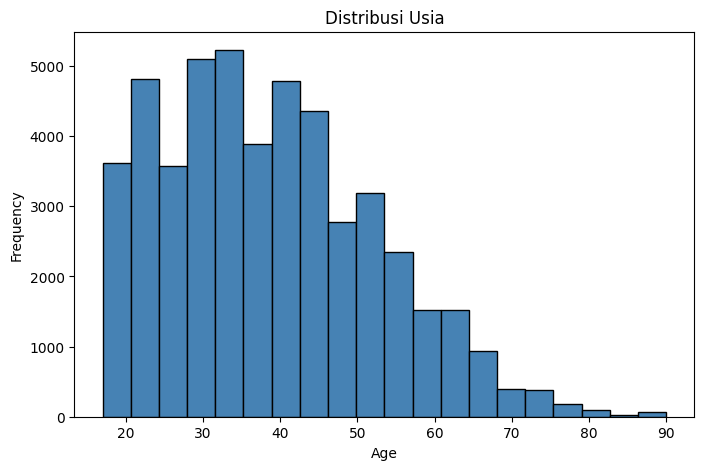

In [59]:
#Jawab 2.1.1 - Histogram
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, color="steelblue", edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribusi Usia")
plt.show()

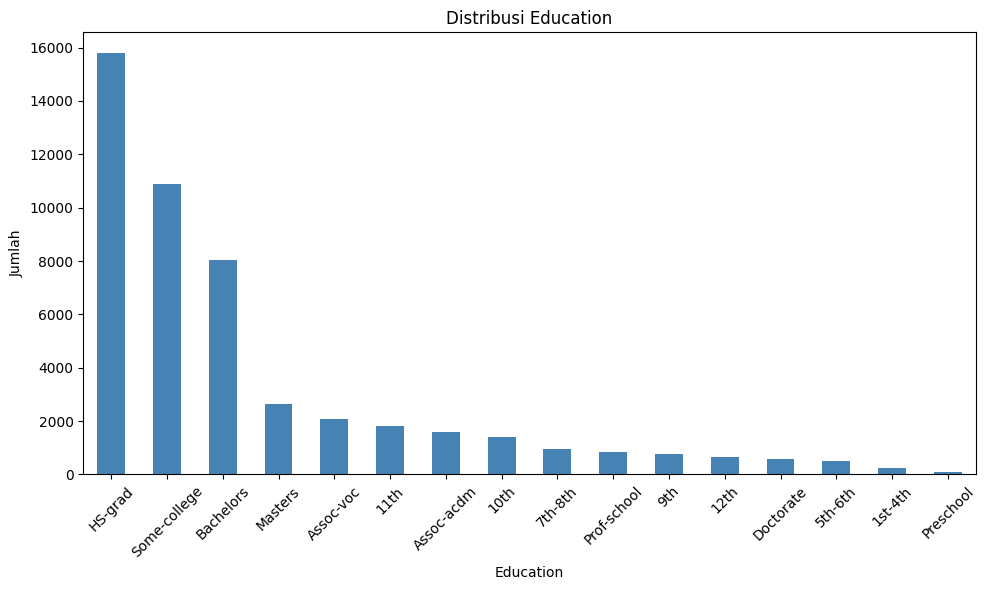

In [58]:
#Jawab 2.1.2 - Barchart
plt.figure(figsize=(10, 6))
df['education'].value_counts().plot(kind='bar', color='steelblue')
plt.xlabel("Education")
plt.ylabel("Jumlah")
plt.title("Distribusi Education")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

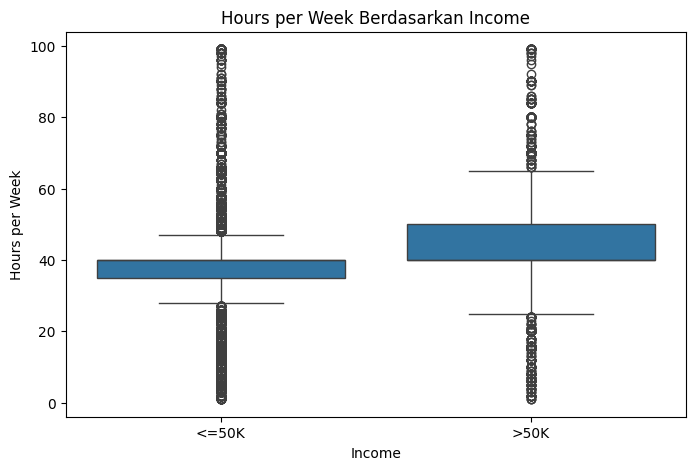

In [60]:
#Jawab 2.1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="hours-per-week")

plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.title("Hours per Week Berdasarkan Income")
plt.show()

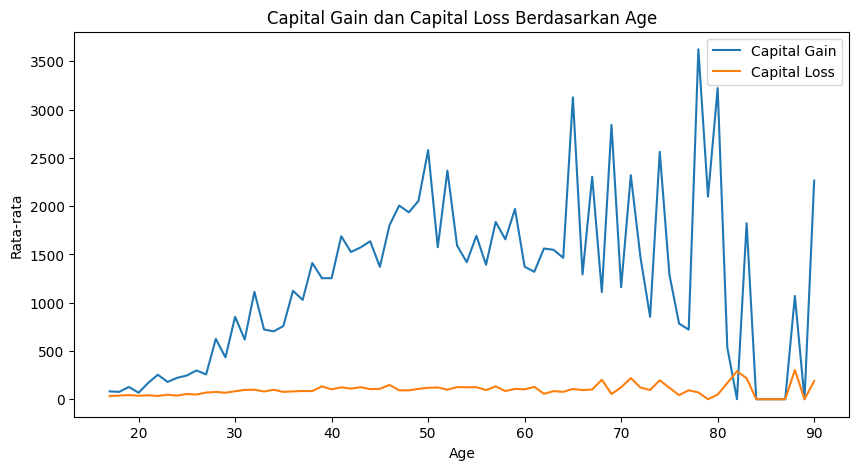

In [61]:
#Jawab 2.1.4 - Lineplot
data_age = df.groupby("age")[["capital-gain", "capital-loss"]].mean()
plt.figure(figsize=(10, 5))

plt.plot(data_age.index, data_age["capital-gain"], label="Capital Gain")
plt.plot(data_age.index, data_age["capital-loss"], label="Capital Loss")

plt.xlabel("Age")
plt.ylabel("Rata-rata")
plt.title("Capital Gain dan Capital Loss Berdasarkan Age")

plt.legend()
plt.show()

Soal 2 - Analisis Visual
1. Fenomena apa yg terjadi pada distribusi data 'age'?
2. Jika terdapat data yg hilang pada variabel 'age', strategi apa yg diterapkan? mengapa?
3. Berapa jumlah outlier setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yg paling banyak memiliki outlier?


Jawab 2.2.1 - Fenomena distribusi age:
```
Distribusi usia tidak merata, miring ke kanan right-skewed.
Sebagian besar responden berada di usia produktif antara 20-25 tahun, kemudian jumlahnya menurun tajam untuk usia lansia di atas 60 tahun.
```

Jawab 2.2.2 - Strategi missing value pada age:
```
Jika terdapat data hilang pada kolom age, strateginya menggunakan mean.
Karena sebaran data age bersifat skewed/tidak simetris, nilai median lebih stabil dan tidak gampang terpengaruh oleh outlier daripadaa mean.
```

In [27]:
#Jawab 2.2.3 - Menghitung outlier hour-per-week berdasarkan income

for income_group in df["income"].unique():
    data = df[df["income"] == income_group]["hours-per-week"]

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]
    print(f"{income_group}: {len(outliers)} outlier")

<=50K: 11706 outlier
>50K: 781 outlier



> **Bagian 3 - Encoding Variabel Kategorical**

Soal 1
1. Lakukan encoding pada 'Sex' dan 'Income'

In [28]:
#Jawab 3.1

#Encoding Sex
df["sex_encoded"] = df["sex"].map({"Female": 0,"Male": 1})

#Encoding Income
df["income_encoded"] = df["income"].map({"<=50K": 0,">50K": 1})

#Hasil
print(df[["sex","sex_encoded","income","income_encoded"]].head())

      sex  sex_encoded income  income_encoded
0    Male            1  <=50K               0
1    Male            1  <=50K               0
2    Male            1  <=50K               0
3    Male            1  <=50K               0
4  Female            0  <=50K               0



> **Bagian 4 - Analisis Korelasi**

Soal 1
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

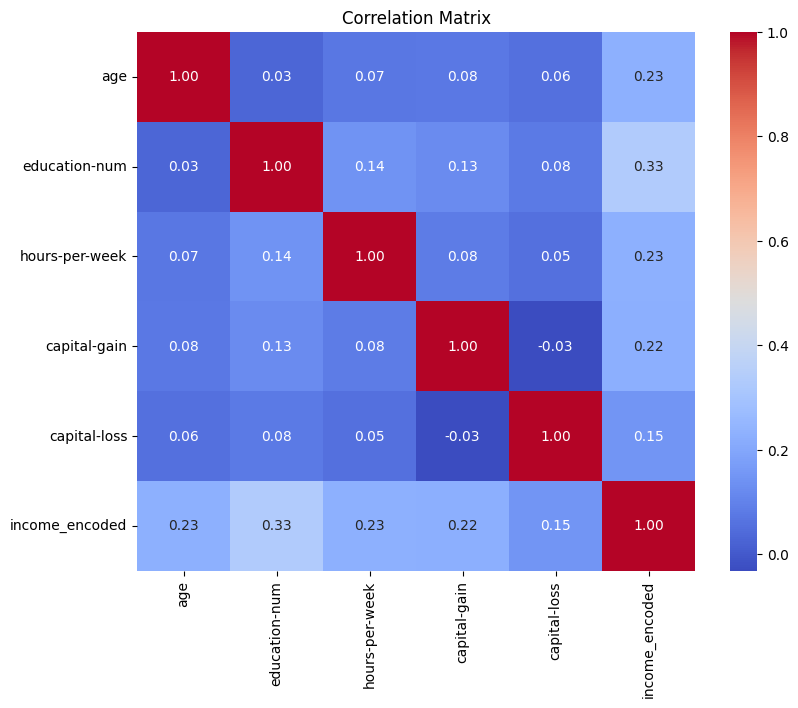

income_encoded    1.000000
education-num     0.332613
age               0.230369
hours-per-week    0.227687
capital-gain      0.223013
capital-loss      0.147554
Name: income_encoded, dtype: float64


In [31]:
#Jawab 4.1
corr_cols = ["age","education-num","hours-per-week","capital-gain","capital-loss","income_encoded"]
corr = df[corr_cols].corr()
plt.figure(figsize=(9, 7))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

income_encoded_corr = corr["income_encoded"].sort_values(ascending=False)
print(income_encoded_corr)

Jawab 4.2 - Hasil Analisis

```
- Variabel education-num berkorelasi positif tinggi terhadap income_encoded (r = 0.33). Semakin tinggi tingkat pendidikan seseorang, semakin besar peluangnya untuk memiliki penghasilan di atas 50K.
- Variabel age dan hours-per-week menunjukkan korelasi positif sedang. Pengalaman kerja seiring bertambahnya usia serta durasi jam kerja mingguan yang lebih lama berbanding lurus dengan peningkatan pendapatan.
- Korelasi positif juga terlihat pada capital-gain dan capital-loss, menandakan individu berpenghasilan tinggi cenderung aktif dalam investasi atau aktivitas finansial yang mencatatkan gain/loss.
- Semua variabel numerik yang diuji memiliki korelasi searah (positif) terhadap income, namun tingkat korelasi keseluruhannya berada di rentang lemah hingga sedang (di bawah 0.40).


> **Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST**

Pada bagian ini, melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [32]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


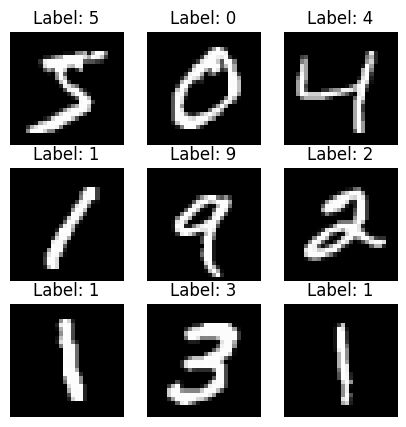

In [33]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

Soal 1
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [34]:
#Jawab 5.1.1 - Unpsampling citra menjadi uk. 32x32

from tensorflow.image import resize

#array kosong untuk menampung hasil
X_test_upsampled = np.empty((X_test.shape[0], 32, 32))

#Upsampling semua data test
for i in range(X_test.shape[0]):
    X_test_upsampled[i] = resize(X_test[i][..., np.newaxis],(32, 32)).numpy().squeeze()

print("Shape sebelum:", X_test.shape)
print("Shape setelah:", X_test_upsampled.shape)

Shape sebelum: (10000, 28, 28)
Shape setelah: (10000, 32, 32)


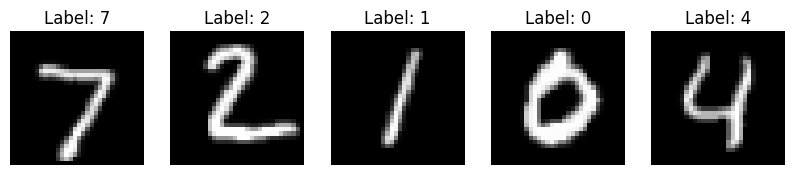

In [35]:
#Jawab 5.1.2 - Tampilkan 5 data hasil unpsampling

plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i],cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.show()

Soal 2

Lakukan normalisasi nilai citra setiap piksel menjadi rentang 0-1

In [36]:
#Jawab 5.2 - normalisai

X_test_normalized = X_test_upsampled / 255.0

print("Minimum:", X_test_normalized.min())
print("Maximum:", X_test_normalized.max())

Minimum: 0.0
Maximum: 1.0


Soal 3

Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Harus membuat holder array kososng untuk menampung hasilnya

In [37]:
#Jawab 5.3

#Holder array kosong
X_test_flattened = np.empty((X_test_normalized.shape[0], 32 * 32))

#Flatten semua data test
for i in range(X_test_normalized.shape[0]):
    X_test_flattened[i] = X_test_normalized[i].reshape(-1)

print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape setelah flatten:", X_test_flattened.shape)

Shape sebelum flatten: (10000, 32, 32)
Shape setelah flatten: (10000, 1024)
